# Snow Water Equivalent (SWE) Example

CanSWE is a dataset that includes Pan-Canadian observations of Snow Water Equivalent (SWE). The data is collected by national, provicial and territorial agencies as well as academic institutions, hydropower companies and their partners. <br> <br>
For more information or to view the dataset, please refer to: https://zenodo.org/records/7734616. <br> <br>

#### Brief Explanation of Key Columns
In this dataset, we are primarily interested in the water equivalent of snow ($kg/m^2$), snow depth (m), and snowpack bulk density ($kg/m^3$). Some other key columns include the station identification code, station name, station elevation, station latitude/longitude, and time. The quality control flags are outlined in the 4 rightmost columns of this SWE dataset.

## Requirements
First, we import all necessary Python libraries. Some of these are standard Python libraries, while others are third-party libraries that must first be installed in your Python environment.

In [1]:
# Data libraries
import numpy as np
import pandas as pd

# Plotting libraries
import matplotlib.pyplot as plt 
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib.path import Path
import matplotlib.colors as mcolors
from matplotlib import cm

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.feature as cf

## Exploration

To begin, we will read the CanSWE dataset into a pandas dataframe using the read_csv() function. We set the 'low_memory' argument to false because we don't want to process the csv file in chunks as it may cause some mixed type inferences. Furthermore, we include the 'dtype' argument to specify a data type to each column so we can get all the data in the proper format and avoid unexpected behaviours. Once this step is completed, we will display the first 6 rows of the data using the head(n) command where n is an integer representing the first 'n' number of rows that should be printed.

In [2]:
import datetime
df = pd.read_csv('CanSWE-CanEEN_1928-2022_v5.csv', low_memory=False,
                 dtype = {'a': 'str', 'c': 'Int64', 'd': 'Int64', 'e': 'Int64',
                          'f': 'str', 'g': 'str', 'h': 'str', 'i': 'str', 'j': 'str', 'k': 'str',
                          'l': 'Int64', 'm': 'Int64', 'n': 'Int64', 'o': 'Int64',
                          'p': 'str', 'q': 'str', 'r': 'str', 's': 'str'})
df.head(6)

,station_id,time,lat,lon,elevation,source,station_name,station_name_sec,station_name_ter,station_id_sec,station_id_ter,type_mes,snw,snd,den,data_flag_snw,data_flag_snd,qc_flag_snw,qc_flag_snd
0,ALE-05AA805,1965-04-06,49.266666,-114.35,1525.0,Alberta Environment,WEST CASTLE SNOW,WEST CASTLE,WEST CASTLE OPEN,SCD-AL219,SCD-AL221,0,688.0,1.76,390.90910,b'',b'',b'',b''
1,ALE-05AA805,1968-03-06,49.266666,-114.35,1525.0,Alberta Environment,WEST CASTLE SNOW,WEST CASTLE,WEST CASTLE OPEN,SCD-AL219,SCD-AL221,0,155.0,0.36,430.55554,b'',b'',b'',b''
2,ALE-05AA805,1968-04-03,49.266666,-114.35,1525.0,Alberta Environment,WEST CASTLE SNOW,WEST CASTLE,WEST CASTLE OPEN,SCD-AL219,SCD-AL221,0,269.0,0.59,455.93220,b'',b'',b'',b''
3,ALE-05AA805,1969-04-01,49.266666,-114.35,1525.0,Alberta Environment,WEST CASTLE SNOW,WEST CASTLE,WEST CASTLE OPEN,SCD-AL219,SCD-AL221,0,378.0,0.98,385.71430,b'',b'',b'',b''
4,ALE-05AA805,1970-04-02,49.266666,-114.35,1525.0,Alberta Environment,WEST CASTLE SNOW,WEST CASTLE,WEST CASTLE OPEN,SCD-AL219,SCD-AL221,0,335.0,0.98,341.83673,b'',b'',b'',b''
5,ALE-05AA805,1971-04-06,49.266666,-114.35,1525.0,Alberta Environment,WEST CASTLE SNOW,WEST CASTLE,WEST CASTLE OPEN,SCD-AL219,SCD-AL221,0,356.0,0.91,391.20880,b'',b'',b'',b''


#### Finding a Station With Most Entries
To achieve a good understanding of how snow water equivalent evolves over time, we should search the dataset for a station with the most entries. We can accomplish this by using a linear search algorithm to iterate through the Pandas dataframe to find this station.

In [3]:
stn = ''
maxStn = ''
count = 0
maxCount = 0
i = 0
tempIndex = 0
longitude = 0
latitude = 0
for index, row in df.iterrows():
    if stn == '' and count == 0:
        stn = row['station_id']
        count = count + 1
    elif row['station_id'] == stn:
        count = count + 1
    else:
        if count > maxCount:
            maxCount = count
            maxStn = stn
            i = tempIndex
            longitude = df['lon'][i]
            latitude = df['lat'][i]
        stn = row['station_id']
        count = 1
        tempIndex = index
stn = maxStn
        
print('Station name with the most entries: ' + maxStn)
print('Number of entries: '+ str(maxCount))
print('First appearence of this station ID appears in the dataset at index: '+ str(i))
print('Longitude of the station: '+str(longitude))
print('Latitude of the station: '+str(latitude))

Station name with the most entries: BCE-2G03P
Number of entries: 16457
First appearence of this station ID appears in the dataset at index: 695424
Longitude of the station: -120.7725
Latitude of the station: 49.09414


From the search, the station with the most entries is Station BCE-2G03P. The official name of station BCE-2G03P is Blackwall Peak-Pillow. It is located in British Columbia, and it has a latitude of 49.454445 (degrees North) and a longitude of -123.031944 (degrees East). The elevation there is 1940 meters.

#### Code For Creating a Contour Plot
Below is a Python function called createContourPlot() that uses the Matplotlib and Cartopy libraries to create a contour plot, which helps us visualize the geographical locations of various stations. <br>
This function takes in a few arguments: The longitude and latitude coordinates of each station, the longitude and the latitude coordinates of a corresponding station ID label, and a list of the station IDs we would like to plot.

In [4]:
def createContourPlot(x, y, xLabel, yLabel, stnIDs):
    figure = plt.figure(figsize = (11, 7))
    ax = figure.add_subplot(1, 1, 1, projection = ccrs.PlateCarree())
    ax.set_extent([-135, -110, 46, 59]) #(x0, x1, y0, y1)
    ax.coastlines()
    plt.xticks(range(-135, -109), range(-135, -109), fontsize = 6)
    plt.yticks(range(46, 60), range(46, 60), fontsize = 6)

    #g1 = ax.gridlines(crs = ccrs.PlateCarree(), draw_labels= True, linestyle = '--')
    #g1.xlocator = mticker.FixedLocator([longitude, longitude2, longitude3])
    #g1.ylocator = mticker.FixedLocator([latitude, latitude2, latitude3])
    states_provinces = cfeature.NaturalEarthFeature(
        category ='cultural',
        name ='admin_1_states_provinces_lines',
        scale ='50m',
        facecolor = 'none')

    countries = cfeature.NaturalEarthFeature(
        category = 'cultural',
        name = 'admin_0_boundary_lines_land',
        scale = '50m',
        facecolor = 'none')

    oceans = cfeature.NaturalEarthFeature(
        'physical', 
        'ocean', 
        scale = '50m', 
        facecolor = cfeature.COLORS['water'])

    land = cfeature.NaturalEarthFeature(
        'physical', 
        'land', 
        scale = '50m',
        facecolor = cfeature.COLORS['water'])

    ax.plot(x, y, marker = 'o', color='blue', markersize = 5, linestyle='')
    for i in range(0, len(stnIDs)):
        ax.text(xLabel[i], yLabel[i], stnIDs[i], fontsize = 8)
    ax.add_feature(cfeature.LAND, facecolor = 'beige')
    ax.add_feature(oceans)

    ax.add_feature(states_provinces, linestyle = '--', linewidth = 0.7)
    ax.add_feature(countries, linestyle = '--', linewidth = 0.7)
    plt.show()

#### Plotting The Geographical Location of Station BCE-2G03P
From the beginning of this tutorial, we note that longitude/latitude are some of the key columns of this CanSWE dataset. As a result, we can call our createContourPlot() function to plot the location of Station BCE-2G03P.

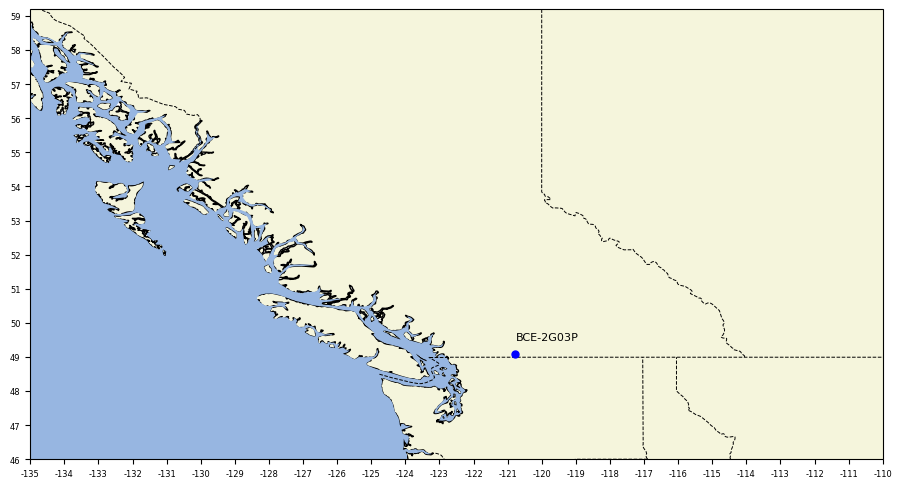

In [5]:
def locations():
    return np.array([[longitude, latitude]])
x, y = locations().T
createContourPlot(x, y, x, y + np.repeat(0.4, len(x)), np.repeat(maxStn, len(x)))

#### Extracting Data For Station BCE-2G03P into a Separate List
After plotting the geographical location of Station BCE-2G03P, the next step is to extract the snow water equivalent, snow depth, and snowpack bulk density data of this station for this station.

In [6]:
from datetime import datetime, timedelta

#Locating indices to determine where the station BCE-2G03P data is
begin = i
end = begin + maxCount - 1

#Creating a dataframe with just station BCE-2G03P data
reducedDf = df.loc[begin:end]

#Extracting the time periods, snow water equivalent, snow depth and snowpack bulk density into their own lists
snw = reducedDf['snw']
snd = reducedDf['snd']
den = reducedDf['den']
time = []
for i in reducedDf['time']:
   time.append(datetime.strptime(i,'%Y-%m-%d').date())

#### Code For Creating a Times Series Graph
Below is a Python function called createTimeSeries() that uses the Matplotlib library to create a time series graph, which helps us visualize trends in snow water equivalent, snow depth and snowpack bulk density. <br>
This function takes in a few arguments: Data for the x-axis (which is normally time in this tutorial), data for the y-axis, a station ID label, a title for the graph, an x-axis label for the graph, a y-axis label for the graph, the lower bound on the x-axis, the upper bound on the x-axis, and a boolean variable isLegend for whether we should display a legend or not.

In [7]:
def createTimeSeries(x, y, label, title, xaxis, yaxis, begin, end, isLegend):
    figure, ax = plt.subplots(figsize=(11, 4.8))
    ax.set_title(title)
    ax.set_xlabel(xaxis)
    ax.set_ylabel(yaxis)
    ax.set_xlim(begin, end)
    for i in range(0, len(x)):
        ax.scatter(x[i], y[i], s = 2, label = label[i])
    if (isLegend):
        ax.legend()
    plt.show()

#### Plotting The Snow Water Equivalent Data For Station BCE-2G03P
We now use the createTimeSeries() function to plot the snow water equivalent data for this station.

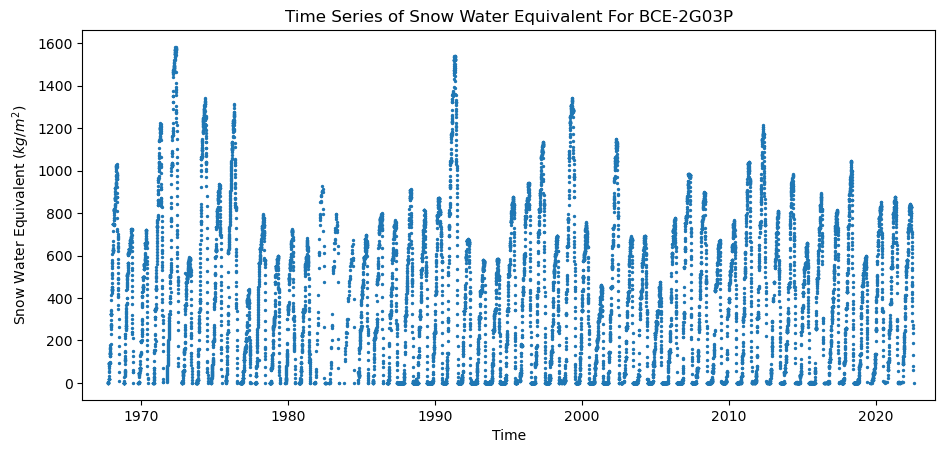

In [8]:
title = 'Time Series of Snow Water Equivalent For '+maxStn
xaxis = 'Time'
yaxis = 'Snow Water Equivalent ($kg/m^2$)'

createTimeSeries([time], [snw], [maxStn], 
                 title, xaxis, yaxis, datetime(1966, 1, 1).date(), datetime(2024, 1, 1), False)

#### Plotting The Snow Depth Data For Station BCE-2G03P
Secondly, we use the createTimeSeries() function to plot the snow depth data for Station BCE-2G03P.

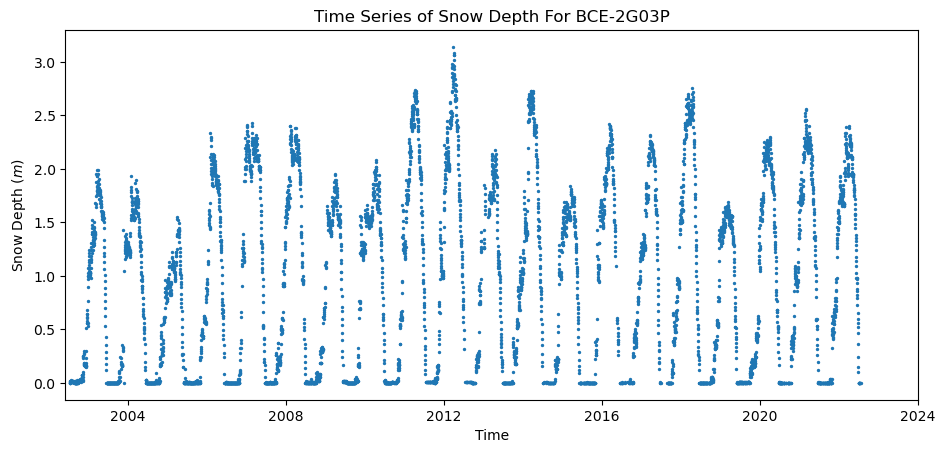

In [9]:
title = 'Time Series of Snow Depth For '+maxStn
xaxis = 'Time'
yaxis = 'Snow Depth ($m$)'
createTimeSeries([time], [snd], [maxStn], 
                 title, xaxis, yaxis, datetime(2002, 6, 1).date(), datetime(2024, 1, 1), False)

#### Plotting The Time Series of Snowpack Bulk Density Data For Station BCE-2G03P
Thirdly, we use the createTimeSeries() function to plot the snowpack bulk density data for Station BCE-2G03P.

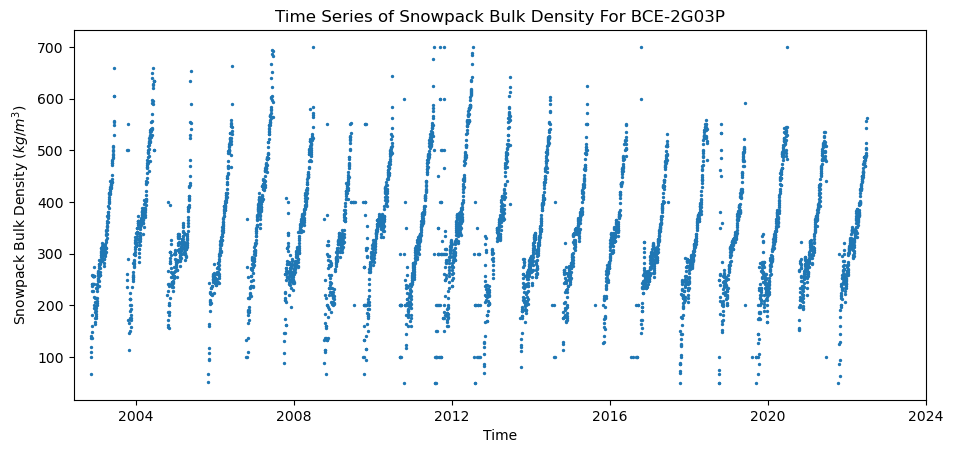

In [10]:
title = 'Time Series of Snowpack Bulk Density For '+maxStn
xaxis = 'Time'
yaxis = 'Snowpack Bulk Density ($kg/m^3$)'
createTimeSeries([time], [den], [maxStn], 
                 title, xaxis, yaxis, datetime(2002, 6, 1).date(), datetime(2024, 1, 1), False)

#### Finding The Number of Stations in British Columbia

In [11]:
stnCount = 0
source = 'British Columbia Environment'
currentStn = ''
for index, row in df.iterrows():
    tempSource = row['source']
    tempStn = row['station_id']
    if source == tempSource and currentStn != tempStn:
        stnCount = stnCount + 1
        currentStn = tempStn
        
print('Number of Stations in British Columbia: '+ str(stnCount))

Number of Stations in British Columbia: 525


Among the 525 stations in British Columbia, we have seen the evolution of Snow Water Equivalent, Snow Depth and Snowpack Bulk Density for Station BCE-2G03P. In this next section of the tutorial, we will contninue to work with station BCE-2G03P, but we will also work with 2 nearby stations, which are stations BCE-2F05P and BCE-2F10P.

#### Introducing Stations BCE-2F05P and BCE-2F10P

The official name of station BCE-2F05P is Mission Creek-Pillow. It has a latitude of 49.94467 (degrees North), a longitude of -118.9497 (degrees East), and an elevation of 1780 meters. <br>
The official name of station BCE-2F10P is Silver Star Mountain. It has a latitude of 50.37136 (degrees North), a longitude of -119.06211 (degrees East), and an elevation of 1840 meters.

#### Plotting The Geographical Location of Stations BCE-2G03P, BCE-2F05P and BCE-2F10P
Using our createContourPlot() function again, we will plot these 3 stations on one graph to illustrate where they are located and how close they are to one another.

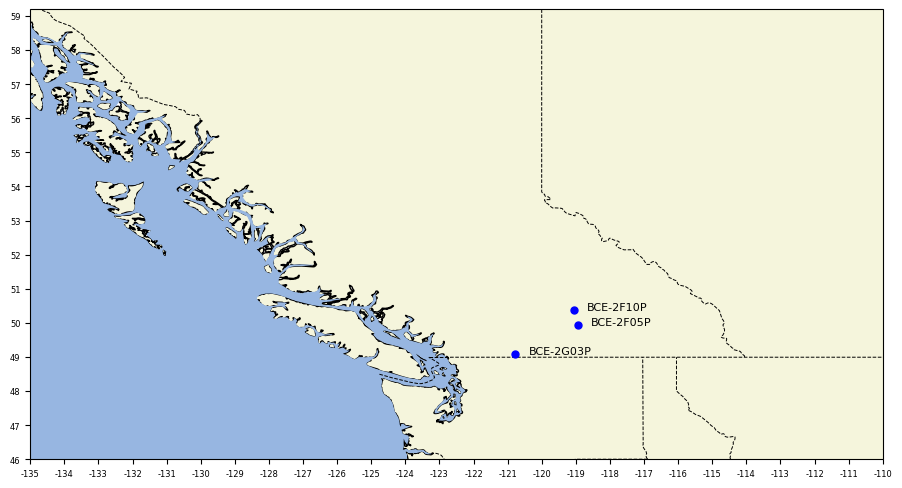

In [12]:
#Station BCE-2F05P
stn2 = 'BCE-2F05P'
latitude2 = 49.94467
longitude2 = -118.9497

#Station BCE-2F10P
stn3 = 'BCE-2F10P'
latitude3 = 50.37136
longitude3 = -119.06211

def locations():
    return np.array([[longitude, latitude], [longitude2, latitude2], [longitude3, latitude3]])

x, y = locations().T
stnIDs = [maxStn, stn2, stn3]
createContourPlot(x, y, x + np.repeat(0.4, len(x)), y, stnIDs)

#### Extracting Data For Stations BCE-2F05P and BCE-2F10P into Separate Lists
In this section of the tutorial, we will compare the data that is found in Stations BCE-2G03P, BCE-2F05P and BCE-2F10P. However, before this comparison, we first need to interate through the SWE Pandas dataframe to find where the data for Stations BCE-2F05P and BCE-2F10P are located. Then, we will extract the snow water equivalence, snow depth, and snowpack bulk density data for these 2 stations.

In [13]:
length = len(time)

#Station BCE-2F05P
#Finding where the Station BCE-2F05P data is
i2 = -1
count2 = 0
for index, row in df.iterrows():
    if row['station_id'] == 'BCE-2F05P':
        i2 = index
        break

for index, row in df.iterrows():
    if row['station_id'] == 'BCE-2F05P':
        count2 = count2 + 1

#Extracting the time period, snow water equivalent, snow depth, and snowpack bulk density into their own lists
begin2 = i2
end2 = begin2 + count2 - 1
reducedDf2 = df.loc[begin2:end2]
snw2 = reducedDf2['snw']
snd2 = reducedDf2['snd']
den2 = reducedDf2['den']

time2 = []
for i in reducedDf2['time']:
   time2.append(datetime.strptime(i,'%Y-%m-%d').date())

#Station BCE-2F10P
#Finding where the Station BCE-2F10P data is
i3 = -1
count3 = 0
for index, row in df.iterrows():
    if row['station_id'] == 'BCE-2F10P':
        i3 = index
        break

for index, row in df.iterrows():
    if row['station_id'] == 'BCE-2F10P':
        count3 = count3 + 1

#Extracting the time period, snow water equivalent, snow depth, and snowpack bulk density into their own lists
begin3 = i3
end3 = begin3 + count3 - 1
reducedDf3 = df.loc[begin3:end3]
snw3 = reducedDf3['snw']
snd3 = reducedDf3['snd']
den3 = reducedDf3['den']

time3 = []
for i in reducedDf3['time']:
   time3.append(datetime.strptime(i,'%Y-%m-%d').date())

#### Plotting The Snow Water Equivalent of Stations BCE-2G03P, BCE-2F05P and BCE-2F10P
We use the createTimeSeries() function to plot the SWE data for Stations BCE-2G03P, BCE-2F05P and BCE-2F10P.

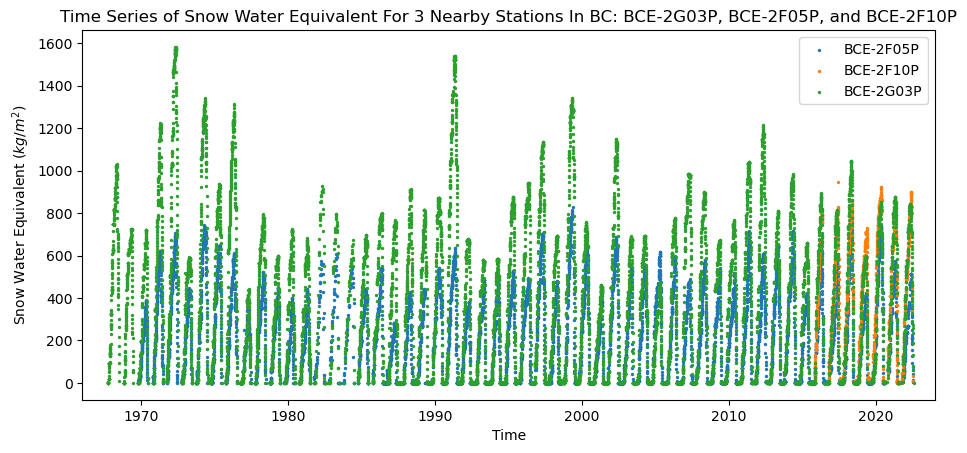

In [14]:
title = 'Time Series of Snow Water Equivalent For 3 Nearby Stations In BC: '+maxStn+', '+stn2+', and '+stn3
xaxis = 'Time'
yaxis = 'Snow Water Equivalent ($kg/m^2$)'
createTimeSeries([time2, time3, time], 
                 [snw2, snw3, snw], 
                 [stn2, stn3, maxStn], 
                 title, xaxis, yaxis, datetime(1966, 1, 1).date(), datetime(2024, 1, 1), True)


#### Plotting a Condensed Time Series of Snow Water Equivalent For BCE-2F05P and BCE-2F10P

In the contour plot where we plotted the locations of these 3 stations, we can see that stations BCE-2F05P and BCE-2F10P are extremely close to each other. As a result, we will take a closer look at how their snow water equivalent data differs.

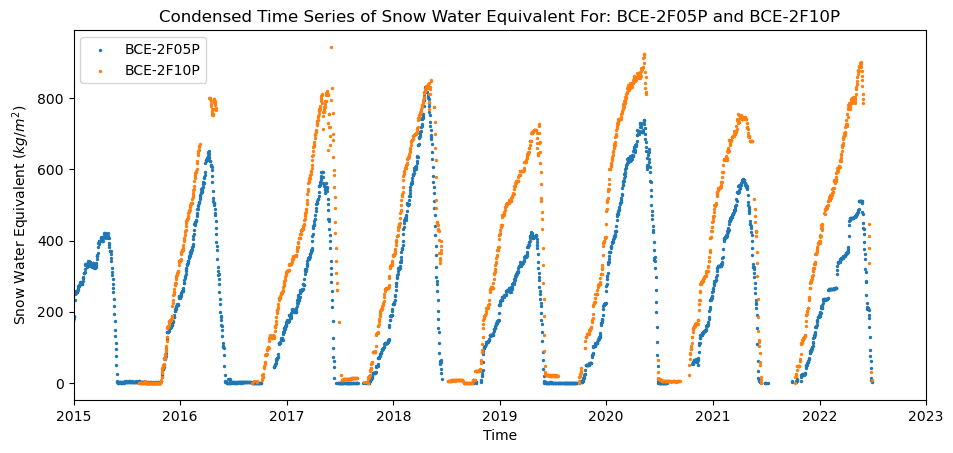

In [15]:
title = 'Condensed Time Series of Snow Water Equivalent For: '+stn2+' and '+stn3
xaxis = 'Time'
yaxis = 'Snow Water Equivalent ($kg/m^2$)'
createTimeSeries([time2, time3],
                 [snw2, snw3], 
                 [stn2, stn3], 
                 title, xaxis, yaxis, datetime(2015, 1, 1).date(), datetime(2023, 1, 1).date(), True)

From the above time series, it can be noted that the trend between these 2 plots are very similar. Nonetheless, Station BCE-2F10P (in orange) tends to have higher peaks.

#### Plotting The Snow Depth of Stations BCE-2G03P, BCE-2F05P and BCE-2F10P
Secondly, we use the createTimeSeries() function to plot the snow depth data for Stations BCE-2G03P, BCE-2F05P and BCE-2F10P.

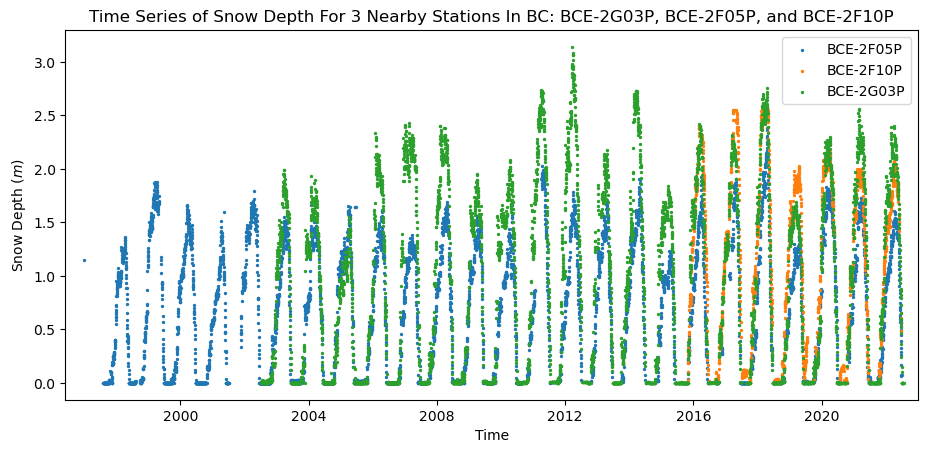

In [16]:
title = 'Time Series of Snow Depth For 3 Nearby Stations In BC: '+maxStn+', '+stn2+', and '+stn3
xaxis = 'Time'
yaxis = 'Snow Depth ($m$)'
createTimeSeries([time2, time3, time],
                 [snd2, snd3, snd], 
                 [stn2, stn3, maxStn], 
                 title, xaxis, yaxis, datetime(1996, 6, 1).date(), datetime(2023, 1, 1).date(), True)

#### Plotting The Snowpack Bulk Density of Stations BCE-2G03P, BCE-2F05P and BCE-2F10P
Thirdly, we use the createTimeSeries() function to plot the snowpack bulk density data for Stations BCE-2G03P, BCE-2F05P and BCE-2F10P.

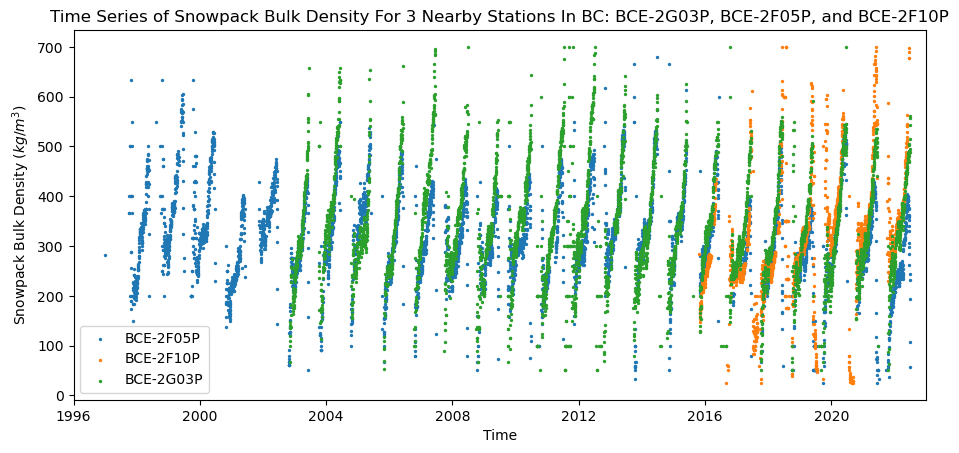

In [17]:
title = 'Time Series of Snowpack Bulk Density For 3 Nearby Stations In BC: '+maxStn+', '+stn2+', and '+stn3
xaxis = 'Time'
yaxis = 'Snowpack Bulk Density ($kg/m^3$)'
createTimeSeries([time2, time3, time], 
                 [den2, den3, den], 
                 [stn2, stn3, maxStn],
                 title, xaxis, yaxis, datetime(1996, 1, 1).date(), datetime(2023, 1, 1).date(), True)

#### Finding a Station in British Columbia With a Snow Water Equivalent Measurement Code of 0
The 3 stations we have examined so far all have a Snow Water Equivalent measurement code of 2, which means the data is sampled using a snow pillow or a snow scale. We also want to determine if different measurement codes  produce different Snow Water Equivalent trends. As a result, we will find a station with the most entries in British Columbia that has a measurement code of 0, which means that this data is sampled using a multi point manual snow survey.

In [18]:
stn4 = ''
maxStn2 = ''
count4 = 0
maxCount2 = 0
i4 = -1
tempIndex2 = -1
longitude5 = 0
latitude5 = 0
for index, row in df.iterrows():
    if row['source'] == 'British Columbia Environment' and row['type_mes'] == 0:
        if stn4 == '' and count4 == 0:
            stn4 = row['station_id']
            count4 = count4 + 1
        elif row['station_id'] == stn4:
            count4 = count4 + 1
        else:
            if count4 > maxCount2:
                maxCount2 = count4
                maxStn2 = stn4
                i4 = tempIndex2
                longitude5 = row['lon']
                latitude5 = row['lat']

            stn4 = row['station_id']
            count4 = 1
            tempIndex2 = index
print('Station With Measurement Code of 0: '+maxStn2)

Station With Measurement Code of 0: BCE-4C03


#### Introducing Stations BCE-4C03, and BCE-2G03
From the linear search above, we found that Station BCE-4C03 is the station with the most entries in British Columbia that has a measurement code of 0. The official name of Station BCE-4C03 is Dease Lake. It has a latitude of 58.42864 (degrees North) and a longitude of -130.0132 (degrees East). The elevation there is 820 meters. <br> <br>
We will also look at Station 2G03, which is another station in British Columbia with a measurement code of 0. The official name of station BCE-2G03 is Blackwall Peak. It has a latitude of 49.1 (degrees North) and a longitude of -120.76667 (degrees East). The elevation there is 1940 meters. <br> <br>
In this section of the tutorial, we will work with 4 stations: BCE-4C03, BCE-2G03, BCE-2G03P and BCE-2F10. The former two are stations we just introduced and each have a measurement code of 0. The latter two are stations we have worked with previously and each have a measurement code of 2.

#### Plotting The Geogphical Locations of BCE-2G03P, BCE-4C03, and BCE-2G03
Using our createContourPlot() function again, we will plot these 4 stations on one graph to illustrate where they are located and how close they are to one another.

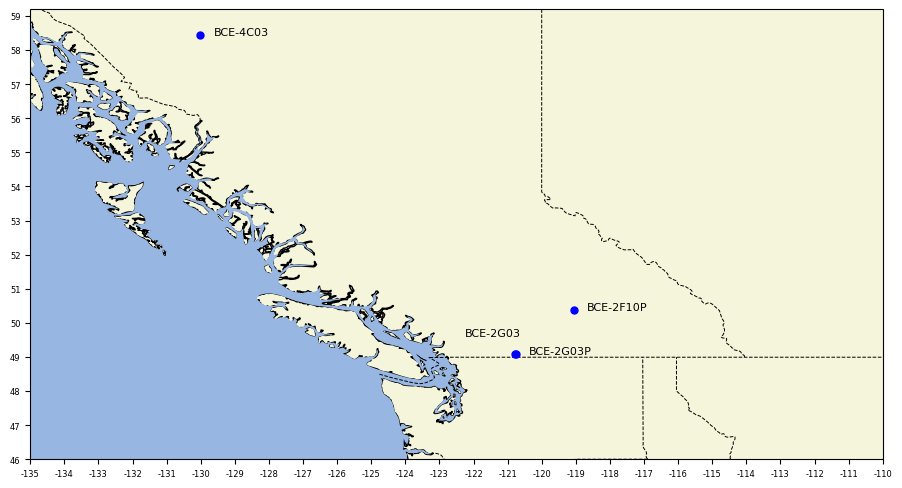

In [19]:
stn4 = 'BCE-4C03'
stn5 = 'BCE-2G03'

#Station BCE-4C03
latitude4 = 58.42864
longitude4 = -130.0132

#Station BCE-2G03
latitude5 = 49.1
longitude5 = -120.76667

def locations():
    return np.array([[longitude, latitude], [longitude3, latitude3], [longitude4, latitude4], [longitude5, latitude5]])
x, y = locations().T
stnIDs = [maxStn, stn3, stn4, stn5]
xLabels = [x[0] + 0.4, x[1] + 0.4, x[2] + 0.4, x[3] - 1.5]
yLabels = [y[0], y[1], y[2], y[3] + 0.5]
createContourPlot(x, y, xLabels, yLabels, stnIDs)


In the above contour plot, we only see 3 blue circle markers because station BCE-2G03P and BCE-2G03 have the exact same longitude and latitude coordinate. 

#### Extracting Data For Stations BCE-2F05P and BCE-2F10P into Separate Lists
In this section of the tutorial, we will compare the data that is found in Stations BCE-4C03, BCE-2G03, BCE-2G03P and BCE-2F10. However, before this comparison, we first need to interate through the SWE Pandas dataframe to find where the data for Stations BCE-4C03 and BCE-2G03 are located. Then, we will extract the snow water equivalence, snow depth, and snowpack bulk density data for these 2 stations.

In [20]:
#Station BCE-4C03
#Finding where the Station BCE-4C03 data is
stn4 = 'BCE-4C03'
i4 = -1
count4 = 0
for index, row in df.iterrows():
    if row['station_id'] == stn4:
        i2 = index
        break

for index, row in df.iterrows():
    if row['station_id'] == stn4:
        count4 = count4 + 1

#Extracting the time period, snow water equivalent, snow depth, and snowpack bulk density into their own lists
begin4 = i4
end4 = begin4 + count4 - 1
reducedDf4 = df.loc[begin4:end4]
snw4 = reducedDf4['snw']

time4 = []
for i in reducedDf4['time']:
   time4.append(datetime.strptime(i,'%Y-%m-%d').date())


#Station BCE-2G03
#Finding where the Station BCE-2G03 data is
stn5 = 'BCE-2G03'
i5 = -1
count5 = 0
for index, row in df.iterrows():
    if row['station_id'] == stn5:
        i5 = index
        break

for index, row in df.iterrows():
    if row['station_id'] == stn5:
        count5 = count5 + 1

#Extracting the time period, snow water equivalent, snow depth, and snowpack bulk density into their own lists
begin5 = i5
end5 = begin5 + count5 - 1
reducedDf5 = df.loc[begin5:end5]
snw5 = reducedDf5['snw']

time5 = []
for i in reducedDf5['time']:
   time5.append(datetime.strptime(i,'%Y-%m-%d').date())


#### Plotting SWE Data For all 4 Stations: BCE-4C03, BCE-2G03, BCE-2G03P and BCE-2F10
We now call the createTimeSeries() function to plot the SWE data for Station BCE-4C03, BCE-2G03, BCE-2G03P and BCE-2F10.

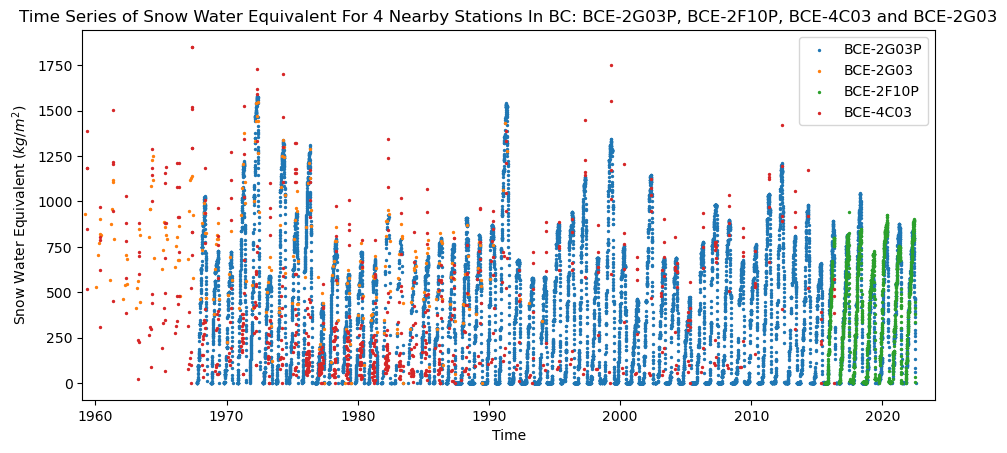

In [28]:
title = 'Time Series of Snow Water Equivalent For 4 Nearby Stations In BC: '+maxStn+', '+stn3+', '+stn4+' and '+stn5
xaxis = 'Time'
yaxis = 'Snow Water Equivalent ($kg/m^2$)'
createTimeSeries([time, time5, time3, time4], 
                 [snw, snw5, snw3, snw4], 
                 [maxStn, stn5, stn3, stn4], 
                 title, xaxis, yaxis, datetime(1959, 1, 1).date(), datetime(2024, 1, 1).date(), True)

#### Plotting SWE Data For BCE-4C03 and BCE-2G03P
In the contour plot where we plotted the locations of these 4 stations, we can see that stations BCE-4C03 and BCE-2G03P are extremely close to each other. As a result, we will take a closer look at how their snow water equivalent data differs.

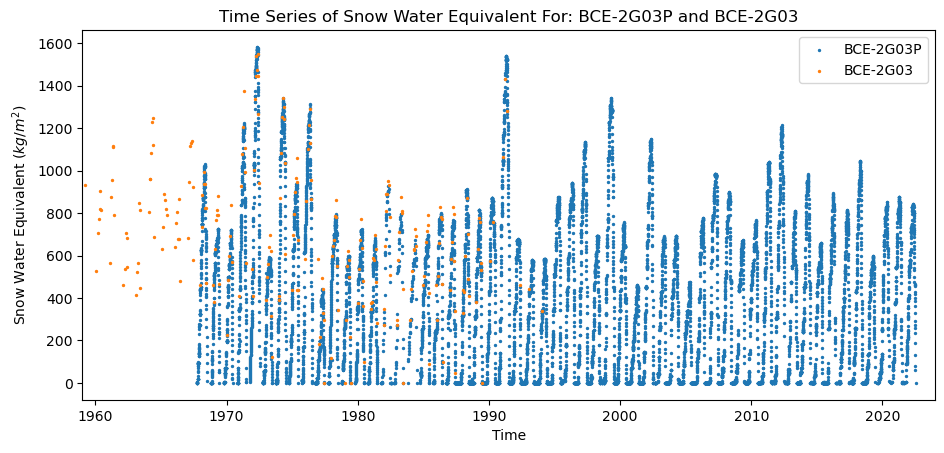

In [29]:
title = 'Time Series of Snow Water Equivalent For: '+maxStn+' and '+stn5
xaxis = 'Time'
yaxis = 'Snow Water Equivalent ($kg/m^2$)'
createTimeSeries([time, time5], 
                 [snw, snw5], 
                 [maxStn, stn5], 
                 title, xaxis, yaxis, datetime(1959, 1, 1).date(), datetime(2024, 1, 1).date(), True)

From the above contour plot, Station BCE-2G03 (in orange), which has a measurement code of 0, has data that is scattered all over the place and does not really follow any sort of trend. Nonetheless, Station BCE-2G03P (in blue), which has a measurement code of 2, has data that follows some sort of sinusoidal trend.

#### Plotting SWE Data For Station BCE-2G03P But Distinguishing Them Based on Quality Flags
Quality flags provides information on the reliability of data in this dataset. For station BCE-2G03P, most of the data is not flagged, which means that it should be reliable. However, there are flags for some data points which could mean the data is missing (M flag), the data is an estimate (E flag) or the data is even revised (R flag). We will now plot the data for station BCE-2G03P and distinguish the data points by their quality flags.

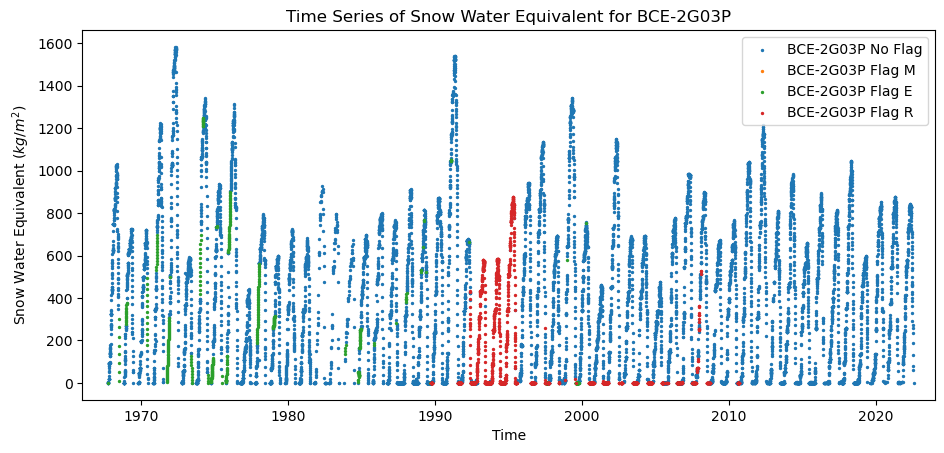

Dates of Missing SWE Data: 
['2002-07-15', '2002-07-16', '2002-07-17', '2002-07-18', '2002-07-19', '2002-07-20', '2002-07-21', '2002-07-22', '2002-07-23', '2002-07-24', '2002-07-25', '2002-07-26', '2002-07-27', '2002-07-28', '2002-07-29', '2002-07-30', '2002-07-31', '2002-08-01', '2002-08-02', '2002-08-03', '2002-08-04', '2002-08-05', '2002-08-06', '2002-08-07', '2002-08-08', '2002-08-09', '2002-08-10', '2002-08-11', '2002-08-12', '2002-08-13', '2002-08-14', '2002-08-15', '2002-08-16', '2002-08-17', '2002-08-18', '2002-08-20', '2002-08-21', '2002-08-22', '2002-08-23', '2002-08-24', '2002-08-25', '2002-08-26', '2002-09-17', '2002-09-18', '2002-09-19', '2002-09-20', '2002-09-22', '2002-09-23', '2002-09-24', '2002-09-25', '2002-09-26', '2002-09-27', '2002-09-28', '2002-09-30', '2002-10-01', '2002-10-02', '2002-10-03', '2002-10-04', '2002-10-05', '2002-10-06', '2002-10-07', '2002-10-08', '2002-10-09', '2002-10-10', '2002-10-11', '2002-10-12', '2002-10-13', '2002-10-14', '2002-10-15', '2002

In [33]:
eFlagTime = []
eFlagSwn = []
rFlagSwn = []
rFlagTime = []
mFlagSwn = []
mFlagTime = []
noFlagTime = []
noFlagSwn = []

for index, row in df.iterrows():
    if row['station_id'] == maxStn:
        if row['data_flag_snw'] == "b'M'":
            mFlagTime.append(datetime.strptime(row['time'],'%Y-%m-%d').date())
            mFlagSwn.append(row['snw'])
        elif row['data_flag_snw'] == "b'E'":
            eFlagTime.append(datetime.strptime(row['time'],'%Y-%m-%d').date())
            eFlagSwn.append(row['snw'])
        elif row['data_flag_snw'] == "b'R'":
            rFlagTime.append(datetime.strptime(row['time'],'%Y-%m-%d').date())
            rFlagSwn.append(row['snw'])
        elif row['data_flag_snw'] == "b''":
            noFlagTime.append(datetime.strptime(row['time'],'%Y-%m-%d').date())
            noFlagSwn.append(row['snw'])

title = 'Time Series of Snow Water Equivalent for '+maxStn
xaxis = 'Time'
yaxis = 'Snow Water Equivalent ($kg/m^2$)'
createTimeSeries([noFlagTime, mFlagTime, eFlagTime, rFlagTime], 
                 [noFlagSwn, mFlagSwn, eFlagSwn, rFlagSwn], 
                 [maxStn+" No Flag", maxStn+" Flag M", maxStn+" Flag E", maxStn+" Flag R"], 
                 title, xaxis, yaxis, datetime(1966, 1, 1).date(), datetime(2024, 1, 1).date(), True)

missingData = []
for index, row in df.iterrows():
    if row['station_id'] == maxStn and row['data_flag_snw'] == "b'M'":
        missingData.append(row['time'])
print("Dates of Missing SWE Data: ")
print(missingData)


From the graph above, we can tell that the estimated data (in green) was present during the 1970s and 1980s. Furthermore, the revised data (in red) was predominately present during the 1990s, but there were also some entries during the 2000s and 2010s. Finally, the missing data is not plotted but the first entry of missing data actually was in 2002.